In [1]:
import json
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RAW_DIR = "../data/raw"

In [2]:
def section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def load_json_lines(path):
    """Load Starbucks newline-delimited JSON files."""
    return pd.read_json(path, orient="records", lines=True)

In [3]:
portfolio_df = load_json_lines(f"{RAW_DIR}/portfolio.json")
profile_df = load_json_lines(f"{RAW_DIR}/profile.json")
transcript_df = load_json_lines(f"{RAW_DIR}/transcript.json")

In [4]:
section("PORTFOLIO.JSON")

print(f"Shape: {portfolio_df.shape}")

print("\nColumns and dtypes:")
display(portfolio_df.dtypes)

print("\nFull Portfolio:")
display(portfolio_df)


PORTFOLIO.JSON
Shape: (10, 6)

Columns and dtypes:


reward         int64
channels      object
difficulty     int64
duration       int64
offer_type    object
id            object
dtype: object


Full Portfolio:


,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"[web, email, mobile, social]",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"[web, email, mobile, social]",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"[email, mobile, social]",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"[web, email, mobile, social]",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"[web, email, mobile]",10,7,discount,2906b810c7d4411798c6938adc9daaa5


In [5]:
print("Offer Type Counts")
display(portfolio_df["offer_type"].value_counts())

discount_ids = portfolio_df.loc[
    portfolio_df["offer_type"] == "discount",
    "id"
].tolist()

print("\nDiscount Offer IDs:")
print(discount_ids)

Offer Type Counts


offer_type
bogo             4
discount         4
informational    2
Name: count, dtype: int64


Discount Offer IDs:
['0b1e1539f2cc45b7b9fa7c272da2e1d7', '2298d6c36e964ae4a3e7e9706d1fb8c2', 'fafdcd668e3743c1bb461111dcafc2a4', '2906b810c7d4411798c6938adc9daaa5']


In [6]:
section("PROFILE.JSON")

print(f"Shape: {profile_df.shape}")

print("\nColumns and dtypes:")
display(profile_df.dtypes)

print("\nSample Records:")
display(profile_df.head())


PROFILE.JSON
Shape: (17000, 5)

Columns and dtypes:


gender               object
age                   int64
id                   object
became_member_on      int64
income              float64
dtype: object


Sample Records:


,gender,age,id,became_member_on,income
0,None,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,None,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,None,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [7]:
print("Missing Values Per Column")
display(profile_df.isna().sum())

Missing Values Per Column


gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

In [8]:
print("Age Summary Statistics")
display(profile_df["age"].describe())

placeholder_count = (profile_df["age"] == 118).sum()

print(f"\nCustomers with age == 118: {placeholder_count}")

Age Summary Statistics


count    17000.000000
mean        62.531412
std         26.738580
min         18.000000
25%         45.000000
50%         58.000000
75%         73.000000
max        118.000000
Name: age, dtype: float64


Customers with age == 118: 2175


In [9]:
print("Income Summary Statistics")
display(profile_df["income"].describe())

print(
    f"\nIncome Missing Count: "
    f"{profile_df['income'].isna().sum()}"
)

Income Summary Statistics


count     14825.000000
mean      65404.991568
std       21598.299410
min       30000.000000
25%       49000.000000
50%       64000.000000
75%       80000.000000
max      120000.000000
Name: income, dtype: float64


Income Missing Count: 2175


In [10]:
print("Sample became_member_on Values")

display(profile_df["became_member_on"].head())

print(
    f"\nDtype: "
    f"{profile_df['became_member_on'].dtype}"
)

Sample became_member_on Values


0    20170212
1    20170715
2    20180712
3    20170509
4    20170804
Name: became_member_on, dtype: int64


Dtype: int64


In [11]:
print("Gender Value Counts")

display(
    profile_df["gender"]
    .value_counts(dropna=False)
)

Gender Value Counts


gender
M       8484
F       6129
None    2175
O        212
Name: count, dtype: int64

In [12]:
section("TRANSCRIPT.JSON")

print(f"Shape: {transcript_df.shape}")

print("\nColumns and dtypes:")
display(transcript_df.dtypes)

print("\nSample Records:")
display(transcript_df.head())


TRANSCRIPT.JSON
Shape: (306534, 4)

Columns and dtypes:


person    object
event     object
value     object
time       int64
dtype: object


Sample Records:


,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [13]:
print("Event Type Counts")

display(
    transcript_df["event"]
    .value_counts()
)

Event Type Counts


event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64

In [14]:
print("Sample 'value' Objects")

for ev in transcript_df["event"].unique():
    sample = transcript_df.loc[
        transcript_df["event"] == ev,
        "value"
    ].iloc[0]

    print(f"\nEvent = {ev}")
    print(sample)

Sample 'value' Objects



Event = offer received
{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}

Event = offer viewed
{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'}

Event = transaction
{'amount': 0.8300000000000001}

Event = offer completed
{'offer_id': '2906b810c7d4411798c6938adc9daaa5', 'reward': 2}


In [15]:
n_customers = transcript_df["person"].nunique()

print(
    f"Unique Customers in Transcript: "
    f"{n_customers}"
)

Unique Customers in Transcript: 17000


In [16]:
sample_customer = transcript_df["person"].iloc[0]

trace = (
    transcript_df[
        transcript_df["person"] == sample_customer
    ]
    .sort_values("time")
)

trace

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
15561,78afa995795e4d85b5d9ceeca43f5fef,offer viewed,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},6
47582,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 19.89},132
47583,78afa995795e4d85b5d9ceeca43f5fef,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,132
49502,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 17.78},144
53176,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},168
85291,78afa995795e4d85b5d9ceeca43f5fef,offer viewed,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},216
87134,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 19.67},222
92104,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 29.72},240
141566,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 23.93},378


In [17]:
print("""
MANUAL RECON QUESTIONS

1. Did this customer receive a discount offer?
2. Which offer ID was received?
3. Did they view it?
4. When did they transact?
5. Was the offer completed?
6. Can purchases be linked to the offer window?

Repeat for 5-10 customers before designing treatment labels.
""")


MANUAL RECON QUESTIONS

1. Did this customer receive a discount offer?
2. Which offer ID was received?
3. Did they view it?
4. When did they transact?
5. Was the offer completed?
6. Can purchases be linked to the offer window?

Repeat for 5-10 customers before designing treatment labels.



In [18]:
transactions = transcript_df[
    transcript_df["event"] == "transaction"
]

per_customer_counts = (
    transactions
    .groupby("person")
    .size()
)

print(
    f"Customers with Transactions: "
    f"{per_customer_counts.shape[0]}"
)

display(
    per_customer_counts.describe()
)

Customers with Transactions: 16578


count    16578.000000
mean         8.381771
std          5.009822
min          1.000000
25%          5.000000
50%          7.000000
75%         11.000000
max         36.000000
dtype: float64

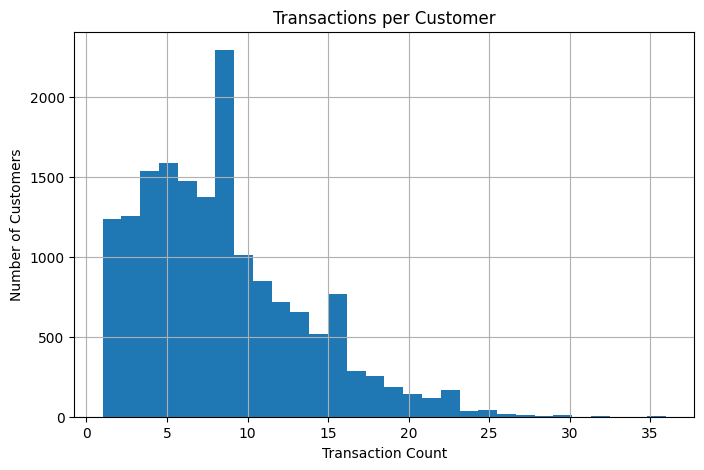

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

per_customer_counts.hist(bins=30)
plt.title("Transactions per Customer")
plt.xlabel("Transaction Count")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
print("""
RECON CHECKLIST

1. Age available?
2. Income available?
3. Tenure derivable from became_member_on?
4. Avg spend derivable?
5. Purchase frequency derivable?
6. Total transactions derivable?
7. Discount offer IDs identified?    
""")


RECON CHECKLIST

1. Age available?
2. Income available?
3. Tenure derivable from became_member_on?
4. Avg spend derivable?
5. Purchase frequency derivable?
6. Total transactions derivable?
7. Discount offer IDs identified?    



In [21]:
duration_hours = (
    portfolio_df
    .set_index("id")["duration"]
    * 24
)

received = (
    transcript_df[
        transcript_df["event"] == "offer received"
    ]
    .copy()
)

received["offer_id"] = received["value"].apply(
    lambda v: v.get("offer id")
)

received["duration_hours"] = (
    received["offer_id"]
    .map(duration_hours)
)

received["window_start"] = received["time"]

received["window_end"] = (
    received["time"]
    + received["duration_hours"]
)

windows_df = received[
    [
        "person",
        "offer_id",
        "window_start",
        "window_end"
    ]
]

windows_df.head()

,person,offer_id,window_start,window_end
0,78afa995795e4d85b5d9ceeca43f5fef,9b98b8c7a33c4b65b9aebfe6a799e6d9,0,168
1,a03223e636434f42ac4c3df47e8bac43,0b1e1539f2cc45b7b9fa7c272da2e1d7,0,240
2,e2127556f4f64592b11af22de27a7932,2906b810c7d4411798c6938adc9daaa5,0,168
3,8ec6ce2a7e7949b1bf142def7d0e0586,fafdcd668e3743c1bb461111dcafc2a4,0,240
4,68617ca6246f4fbc85e91a2a49552598,4d5c57ea9a6940dd891ad53e9dbe8da0,0,120


In [22]:
n_customers_with_offers = (
    windows_df["person"]
    .nunique()
)

n_customers_with_multiple_offers = (
    windows_df
    .groupby("person")
    .size()
    .gt(1)
    .sum()
)

print(
    f"Customers who received at least one offer: "
    f"{n_customers_with_offers}"
)

print(
    f"Customers who received more than one offer: "
    f"{n_customers_with_multiple_offers}"
)

Customers who received at least one offer: 16994
Customers who received more than one offer: 16921


In [23]:
def count_overlaps(windows_df):

    overlap_flags = {}

    for person, group in windows_df.groupby("person"):

        group = (
            group
            .sort_values("window_start")
            .reset_index(drop=True)
        )

        has_overlap = False

        for i in range(len(group) - 1):

            current_end = group.loc[i, "window_end"]
            next_start = group.loc[i + 1, "window_start"]

            if next_start < current_end:
                has_overlap = True
                break

        overlap_flags[person] = has_overlap

    return pd.Series(overlap_flags)

In [24]:
overlap_series = count_overlaps(windows_df)

n_overlap = overlap_series.sum()

pct_overlap = (
    100
    * n_overlap
    / n_customers_with_offers
)

print(
    f"Customers with overlapping offers: "
    f"{n_overlap}"
)

print(
    f"Percentage overlap: "
    f"{pct_overlap:.2f}%"
)

Customers with overlapping offers: 14462
Percentage overlap: 85.10%


In [25]:
discount_ids = set(
    portfolio_df.loc[
        portfolio_df["offer_type"] == "discount",
        "id"
    ]
)

discount_ids

{'0b1e1539f2cc45b7b9fa7c272da2e1d7',
 '2298d6c36e964ae4a3e7e9706d1fb8c2',
 '2906b810c7d4411798c6938adc9daaa5',
 'fafdcd668e3743c1bb461111dcafc2a4'}

In [26]:
def has_discount_overlap(group):

    group = (
        group
        .sort_values("window_start")
        .reset_index(drop=True)
    )

    for i in range(len(group) - 1):

        current_end = group.loc[i, "window_end"]
        next_start = group.loc[i + 1, "window_start"]

        if next_start < current_end:

            ids_involved = {
                group.loc[i, "offer_id"],
                group.loc[i + 1, "offer_id"]
            }

            if ids_involved & discount_ids:
                return True

    return False

In [27]:
discount_overlap_flags = {

    person: has_discount_overlap(group)

    for person, group
    in windows_df.groupby("person")
}

n_discount_overlap = sum(
    discount_overlap_flags.values()
)

pct_discount_overlap = (
    100
    * n_discount_overlap
    / n_customers_with_offers
)

print(
    f"Customers with discount overlap: "
    f"{n_discount_overlap}"
)

print(
    f"Discount overlap percentage: "
    f"{pct_discount_overlap:.2f}%"
)

Customers with discount overlap: 12041
Discount overlap percentage: 70.85%


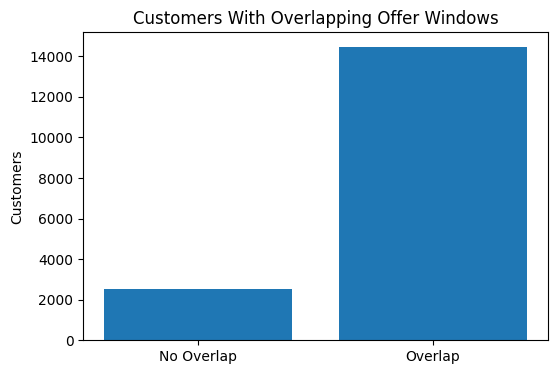

In [28]:
import matplotlib.pyplot as plt

labels = [
    "No Overlap",
    "Overlap"
]

values = [
    n_customers_with_offers - n_overlap,
    n_overlap
]

plt.figure(figsize=(6,4))

plt.bar(labels, values)

plt.title(
    "Customers With Overlapping Offer Windows"
)

plt.ylabel("Customers")

plt.show()

In [ ]:
if pct_discount_overlap < 10:
    print("""
RECOMMENDATION

Discount overlap is rare.

Safest option:
- Exclude overlapping customers
- Report exclusion count
- Proceed with clean treatment/control analysis

This is the simplest and most defensible strategy.
""")
else:
    print("""
RECOMMENDATION

Discount overlap is common.

Excluding these customers may remove a large portion of the dataset.

You should create an attribution rule, such as:
- Most recently viewed offer
- First active offer
- Highest reward offer

Document the assumption carefully.
""")


RECOMMENDATION

Discount overlap is common.

Excluding these customers may remove a large portion of the dataset.

You should create an attribution rule, such as:
- Most recently viewed offer
- First active offer
- Highest reward offer

Document the assumption carefully.

